**What are you trying to do in this notebook?**

This months' TPS competition is on forecasting the number of book sales 2021. In particular, I need to predict the number of sales of four books that two companies sold across six countries. It is reminiscent of the TPS January 2022 that happened earlier this year. For this challenge, I will be predicting a full year worth of sales for 4 items from two competing stores located in six different countries. This dataset is completely fictional, but contains many effects that i see in real world data, eg., weekend and holiday effect, seasonality, etc. My task is to predict book sales during the year 2021.

**Why are trying it?**

This competition is particulary interesting because I'm not only dealing with the usual trends and seasonality patterns, but now are forecasting during 2021 - a volatile year influenced by many factors, e.g., COVID-19.

**Files** -

* train.csv - the training set, which includes the sales data for each date-country-store-item combination.

* test.csv - the test set; your task is to predict the corresponding item sales for each date-country-store-item combination. Note the Public leaderboard is scored on the first quarter of the test year, and the Private on the remaining.

* sample_submission.csv - a sample submission file in the correct format

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/spaceship-titanic/sample_submission.csv
/kaggle/input/spaceship-titanic/train.csv
/kaggle/input/spaceship-titanic/test.csv
/kaggle/input/melbourne-housing-market/Melbourne_housing_FULL.csv
/kaggle/input/melbourne-housing-market/MELBOURNE_HOUSE_PRICES_LESS.csv
/kaggle/input/house-rent-prediction-dataset/Dataset Glossary.txt
/kaggle/input/house-rent-prediction-dataset/House_Rent_Dataset.csv
/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv
/kaggle/input/tabular-playground-series-sep-2022/sample_submission.csv
/kaggle/input/tabular-playground-series-sep-2022/train.csv
/kaggle/input/tabular-playground-series-sep-2022/test.csv


In [2]:
import numpy as np
import pandas as pd

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
from scipy import stats

In [5]:
df_train = pd.read_csv('../input/house-prices-advanced-regression-techniques/train.csv')
df_test = pd.read_csv('../input/house-prices-advanced-regression-techniques/test.csv')

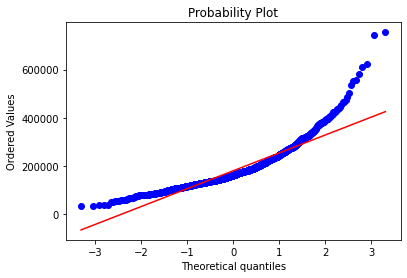

In [6]:
fig = plt.figure()
res = stats.probplot(df_train['SalePrice'], plot=plt)
plt.show()

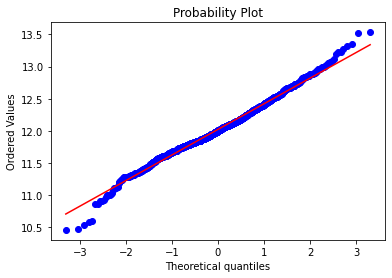

In [7]:
df_train["SalePrice"] = np.log1p(df_train["SalePrice"])

fig = plt.figure()
res = stats.probplot(df_train['SalePrice'], plot=plt)
plt.show()

In [8]:
y_train= df_train['SalePrice']

In [9]:
df = pd.concat((df_train, df_test)).reset_index(drop=True)
df = df.drop(['Id','SalePrice'], axis=1)

In [10]:
df_1 = df.copy()
for feature in ["PoolQC","MiscFeature","Alley","Fence","FireplaceQu",'GarageType','GarageFinish','GarageQual','GarageCond','BsmtQual','BsmtCond','BsmtExposure','BsmtFinType1','BsmtFinType2',"MasVnrType",'MSSubClass']:
    df_1[feature] = df_1[feature].fillna("None")

In [11]:
df_2 = df_1.copy()
for feature in ['GarageYrBlt','GarageArea','GarageCars','BsmtFinSF1','BsmtFinSF2','BsmtUnfSF','TotalBsmtSF','BsmtFullBath','BsmtHalfBath',"MasVnrArea"]:
    df_2[feature] = df_2[feature].fillna(0)

In [12]:
df_3 = df_2.copy()
for feature in ['MSZoning','Electrical','KitchenQual','Exterior1st','Exterior2nd','SaleType']:
    df_3[feature] = df_3[feature].fillna(df_3[feature].mode()[0])

In [13]:
df_4 = df_3.copy()
df_4["Functional"] = df_4["Functional"].fillna("Typ")

In [14]:
df_5 = df_4.copy()
df_5 = df_5.drop(['Utilities'], axis=1)

In [15]:
df_6 = df_5.copy()
df_6["LotFrontage"] = df_6.groupby("Neighborhood")["LotFrontage"].transform(lambda x: x.fillna(x.median()))

In [16]:
df_7 = df_6.copy()
df_7 = pd.get_dummies(df_7)

In [17]:
from sklearn.preprocessing import StandardScaler

In [18]:
df_8 = df_7.copy()
numerical_features = df_8.dtypes[df_8.dtypes != "object"].index

In [19]:
scaler = StandardScaler()
df_8[numerical_features] = scaler.fit_transform(df_8[numerical_features])

In [20]:
df_train = df_8[:df_train.shape[0]]
df_test = df_8[df_train.shape[0]:]

In [21]:
from sklearn.linear_model import LinearRegression

In [22]:
lr = LinearRegression()
lr.fit(df_train, y_train)

LinearRegression()

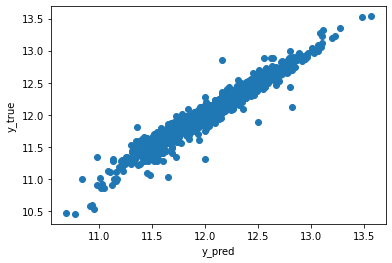

In [23]:
plt.scatter(lr.predict(df_train), y_train)
plt.xlabel('y_pred')
plt.ylabel('y_true')
plt.show()

In [24]:
y_pred = lr.predict(df_test)
y_pred

array([11.71135703, 12.02516928, 12.11882582, ..., 12.07335606,
       11.64648333, 12.30984107])

**Did it work?**

Linear regression is good at extrapolating trends but poor at learning interactions. Coversely, tree-based algorithms like XG Boost are very good at learning interactions but can't extrapolate trends. A hybrid models are try to take the beat of both worlds by first learning the trend with linear interpolation and then learning the interactions ont he detrended time series.

**What did you not understand about it?**

Well, everything provides in the competition data page. I've no problem while working on it. If you guys don't understand the thing that I'll do in this notebook then please comment on this notebook.

This competition is particularly interesting because we are not only dealing with the usual trends and seasonality patterns, but now are forecasting during 2021 - a volatile year influenced by many factors, e.g. COVID-19.

**I Hope you find this notebook useful , Good Luck!**